In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Dataset/final_ml_dataset.csv")

In [4]:
df.head()

,Severity,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,City,State,Start_Lat,Start_Lng,Hour,Month,Day,Is_Weekend,Time_Period
0,3,36.9,91.0,10.0,62,2894,33,39.865147,-84.058723,5,2,7,0,2
1,2,37.9,100.0,10.0,62,10195,33,39.928059,-82.831184,6,2,7,0,2
2,2,36.0,100.0,10.0,88,13347,33,39.063148,-84.032608,6,2,7,0,2
3,3,35.1,96.0,9.0,85,2894,33,39.747753,-84.205582,7,2,7,0,2
4,2,36.0,89.0,6.0,85,2894,33,39.627781,-84.188354,7,2,7,0,2


## Target Variable


In [5]:
y = df["Severity"]

## Seperate Feature and Target

In [6]:
X = df.drop(columns=["Severity"])

## Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

X,
y,

test_size=0.2,

random_state=42

)

## Build Model
Random Forest

In [8]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20,  random_state=42, n_jobs=-1)

## Train model

In [9]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Prediction

In [10]:
y_pred = rf_model.predict(X_test)

## Accuracy

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print("accuracy:", accuracy)

accuracy: 0.8129476182616856


## Precision

In [12]:
precision = precision_score(y_test, y_pred, average="weighted")
print("Precision:", precision)

Precision: 0.8001048177769765


## Recall

In [13]:
recall = recall_score(y_test, y_pred, average="weighted")
print("Recall:", recall)

Recall: 0.8129476182616856


## F1 Score

In [14]:
f1 = f1_score(y_test, y_pred, average="weighted")
print("F1 Score:", f1)

F1 Score: 0.7648720265748613


## Classification Report

In [15]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           1       0.92      0.00      0.01     12759
           2       0.82      0.98      0.89   1137522
           3       0.73      0.23      0.34    258395
           4       0.73      0.04      0.08     39405

    accuracy                           0.81   1448081
   macro avg       0.80      0.31      0.33   1448081
weighted avg       0.80      0.81      0.76   1448081



## Confusion Matrix

In [16]:
cm = confusion_matrix(y_test, y_pred)

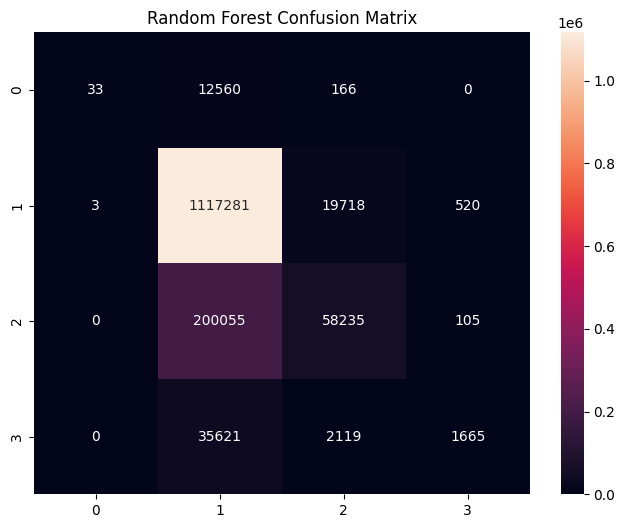

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.title(
"Random Forest Confusion Matrix"
)

plt.savefig(
"../Images/random_forest_confusion_matrix.png"
)

plt.show()

## Feature Importance

In [18]:
importance = pd.DataFrame({'feature': X.columns, 'importance': rf_model.feature_importances_})

In [19]:
importance = importance.sort_values(by='importance', ascending=False)

In [20]:
print(importance.head(10))

              feature  importance
7           Start_Lng    0.229306
6           Start_Lat    0.215267
3   Weather_Condition    0.113948
4                City    0.096115
5               State    0.068623
0      Temperature(F)    0.060159
1         Humidity(%)    0.052035
8                Hour    0.046663
10                Day    0.045008
9               Month    0.038617


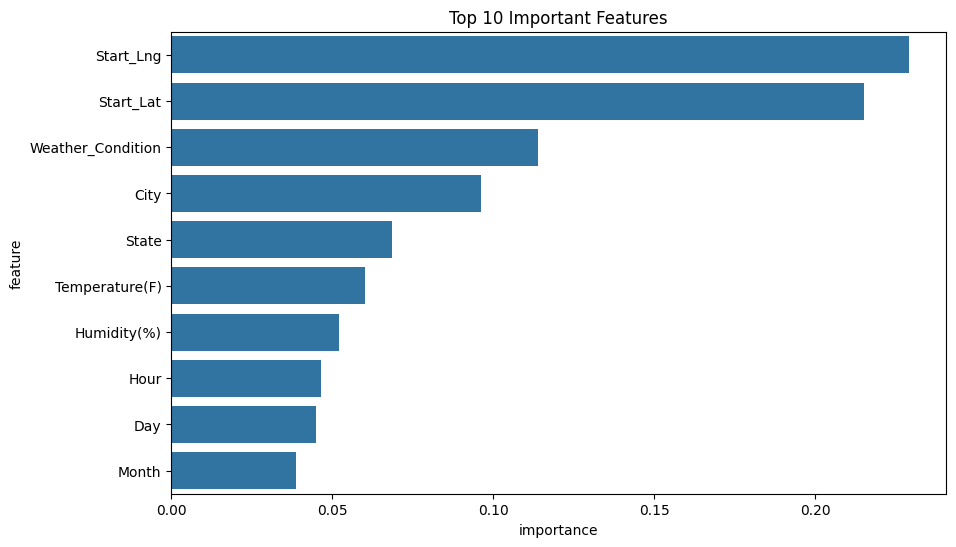

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(

x='importance',

y='feature',

data=importance.head(10)

)

plt.title(
'Top 10 Important Features'
)

plt.savefig(
"../Images/feature_importance_rf.png"
)

plt.show()

In [23]:
import joblib

In [24]:
joblib.dump(rf_model, "../Python/random_forest_model.pkl")

['../Python/random_forest_model.pkl']